In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, Dense, LSTM

In [2]:
ds = xr.open_dataset('sst_nino34_1993_2025.nc')

In [3]:
ds

<xarray.Dataset> Size: 51MB
Dimensions:  (time: 394, lev: 1, lat: 89, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1992-12-01 1993-01-01 ... 2025-09-15
  * lev      (lev) float64 8B 0.0
  * lat      (lat) float64 712B -88.0 -86.0 -84.0 -82.0 ... 82.0 84.0 86.0 88.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    sst      (time, lev, lat, lon) float32 25MB ...
    ssta     (time, lev, lat, lon) float32 25MB ...
Attributes: (12/38)
    Conventions:                CF-1.6, ACDD-1.3
    metadata_link:              https://doi.org/10.7289/V5T72FNM
    id:                         ersst.v5.199212
    naming_authority:           gov.noaa.ncei
    title:                      NOAA ERSSTv5 (in situ only)
    summary:                    ERSST.v5 is developped based on v4 after revi...
    ...                         ...
    platform:                   Ship and Buoy SSTs from ICOADS R3.0 and NCEP GTS
    instrument:                 Conventional thermometers
    source:                     In situ data: ICOADS R3.0 before 2015, NCEP i...
    comment:                    SSTs were observed by conventional thermomete...
    references:                 Huang et al, 2017: Extended Reconstructed Sea...
    climatology:                Climatology is based on 1971-2000 SST, Xue, Y...

In [4]:
enso_df = pd.read_csv('enso_monthly_index_aligned.csv', index_col=0, parse_dates=True)
print(enso_df.head())

            ENSO_SSH_Index
1992-12-01        1.094441
1993-01-01        1.094441
1993-02-01        1.177839
1993-03-01        1.206140
1993-04-01        1.366497


In [5]:
enso_df['ENSO_SSH_Index'].describe()

count    394.000000
mean      -0.229183
std        1.006711
min       -1.980275
25%       -0.995267
50%       -0.397140
75%        0.340869
max        3.517153
Name: ENSO_SSH_Index, dtype: float64

explore data with a few visualizations

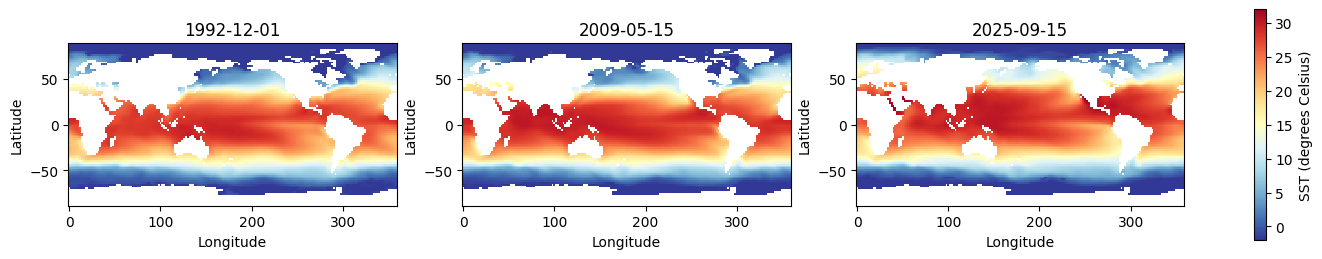

In [6]:
# Select a few time points and see what we're working with
times = [0, len(ds.time)//2, -1]  # first, middle, last

fig, axes = plt.subplots(1, 3, figsize=(18, 3))

for ax, t in zip(axes, times):
    sst = ds.sst.isel(time=t, lev=0)
    im = ax.pcolormesh(ds.lon, ds.lat, sst, cmap='RdYlBu_r', vmin=-2, vmax=32)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(str(ds.time[t].values)[:10])
    ax.set_aspect('equal')
    
plt.colorbar(im, ax=axes, label='SST (degrees Celsius)', orientation='vertical', pad=0.05)
plt.show()

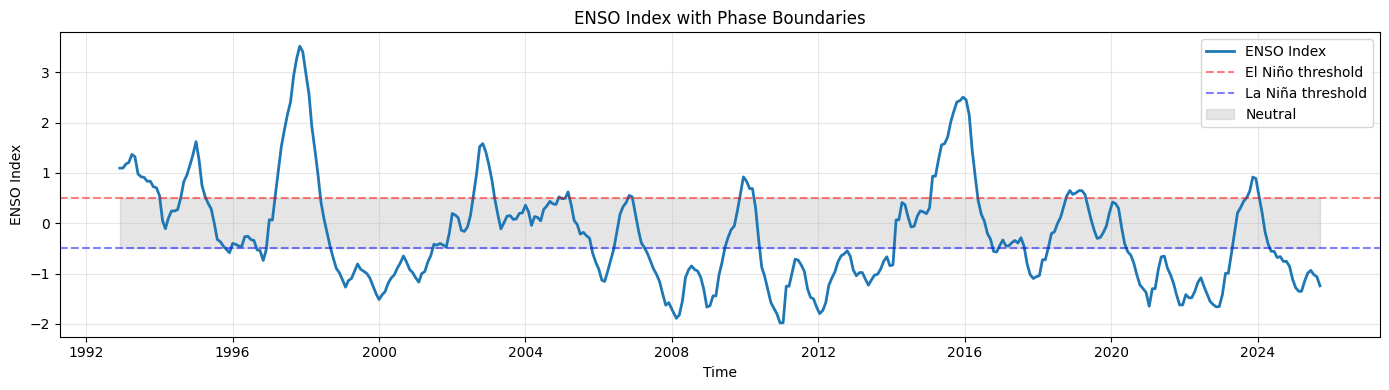

In [7]:
# enso index over time, include classifications of phase
fig, ax1 = plt.subplots(1, 1, figsize=(14, 4))

ax1.plot(ds.time.values, enso_df.values.flatten(), linewidth=2, label='ENSO Index')
ax1.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='El Niño threshold')
ax1.axhline(y=-0.5, color='b', linestyle='--', alpha=0.5, label='La Niña threshold')
ax1.fill_between(ds.time.values, -0.5, 0.5, alpha=0.2, color='gray', label='Neutral')
ax1.set_xlabel('Time')
ax1.set_ylabel('ENSO Index')
ax1.set_title('ENSO Index with Phase Boundaries')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

data preparation

In [ ]:
# use anomaly values
ssta = ds['ssta'].values
ssta = np.squeeze(ssta, axis=1)  # (394, 89, 180)
ssta = np.nan_to_num(ssta, nan=0.0)

ssta_normalized = (ssta - np.mean(ssta)) / np.std(ssta)
ssta_normalized = np.expand_dims(ssta_normalized, axis=-1) 

enso_intensities = enso_df['ENSO_SSH_Index'].values

enso_scaler = StandardScaler()
enso_normalized = enso_scaler.fit_transform(enso_intensities.reshape(-1, 1)).flatten()

print(f"Data shape: {ssta_normalized.shape}")
print(f"Target shape: {enso_normalized.shape}")

dataset = tf.data.Dataset.from_tensor_slices((ssta_normalized, enso_normalized))

Data shape: (394, 89, 180, 1)
Target shape: (394,)


In [10]:
def classify_enso(values):
    classified = np.where(values < -0.5, 0, 
                 np.where(values > 0.5, 2,  
                          1))               
    return classified

In [11]:
class_names = ['La Nina (<-0.5)', 'Neutral', 'El Nino (>0.5)']

limit spatial window to cut out noise & do faster training

In [12]:
lon_mask = (ds.lon >= 190) & (ds.lon <= 240) 
lat_mask = (ds.lat >= -5) & (ds.lat <= 5)    

ssta_enso = ds['ssta'].sel(lon=lon_mask, lat=lat_mask).values
ssta_enso = np.squeeze(ssta_enso, axis=1)

print(f"ENSO region shape: {ssta_enso.shape}")  

ssta_normalized = (ssta_enso - np.mean(ssta_enso)) / np.std(ssta_enso)
ssta_normalized = np.expand_dims(ssta_normalized, axis=-1)

enso_intensities = enso_df['ENSO_SSH_Index'].values
dataset = tf.data.Dataset.from_tensor_slices((ssta_normalized, enso_intensities))

ENSO region shape: (394, 5, 26)


In [ ]:
def create_sequences(data, targets, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(targets[i+seq_length])
    return np.array(X), np.array(y)

In [14]:
seq_length = 12 

X_seq, y_seq = create_sequences(ssta_normalized, enso_intensities, seq_length)
print(f"Sequence shape: {X_seq.shape}")  # (n_samples, seq_length, lat, lon, 1)
print(f"Target shape: {y_seq.shape}")
lat_size, lon_size = ssta_normalized.shape[1:3]

Sequence shape: (382, 12, 5, 26, 1)
Target shape: (382,)


In [15]:
n_samples = len(X_seq)
train_end = int(0.7 * n_samples)
val_end = int(0.85 * n_samples)

X_train, y_train = X_seq[:train_end], y_seq[:train_end]
X_val, y_val = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test, y_test = X_seq[val_end:], y_seq[val_end:]

Train: (267, 12, 5, 26, 1), Val: (57, 12, 5, 26, 1), Test: (58, 12, 5, 26, 1)


In [16]:
cnn_lstm_model = Sequential([
    layers.Input(shape=(seq_length, lat_size, lon_size, 1)),
    
    # TimeDistributed applies the CNN to each timestep independently
    TimeDistributed(layers.Conv2D(32, 3, padding='same', activation='relu')),
    TimeDistributed(layers.BatchNormalization()),
    TimeDistributed(layers.MaxPooling2D(pool_size=(2, 2))),
    
    # TimeDistributed(layers.Conv2D(64, 3, padding='same', activation='relu')),
    # TimeDistributed(layers.BatchNormalization()),
    # TimeDistributed(layers.MaxPooling2D(pool_size=(2, 2))),
    
    # Flatten spatial dims for each timestep, keeping sequence
    TimeDistributed(layers.Flatten()),
    
    # LSTM processes the sequence of CNN features
    LSTM(32, return_sequences=False),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

cnn_lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

cnn_lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 12, 5, 26, 32)  │           320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 12, 5, 26, 32)  │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 12, 2, 13, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 12, 832)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,345 (442.75 KB)

 Trainable params: 113,281 (442.50 KB)

 Non-trainable params: 64 (256.00 B)

In [17]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history_lstm = cnn_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 197ms/step - loss: 0.5964 - mae: 0.5732 - val_loss: 0.2598 - val_mae: 0.4284 - learning_rate: 0.0010
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.4328 - mae: 0.5094 - val_loss: 0.3180 - val_mae: 0.4857 - learning_rate: 0.0010
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.3078 - mae: 0.4299 - val_loss: 0.1830 - val_mae: 0.3527 - learning_rate: 0.0010
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.2726 - mae: 0.3963 - val_loss: 0.2074 - val_mae: 0.3900 - learning_rate: 0.0010
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.2516 - mae: 0.3987 - val_loss: 0.1224 - val_mae: 0.2719 - learning_rate: 0.0010
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.2361 - mae: 0.3725 - val_loss: 0.1780 - val_mae: 0.3578 - learning_rate: 0.0010
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.2571 - mae: 0.3884 - val_loss: 0.1612 - val_mae: 0.3277 - learning_rate: 0.0010
Epoc

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step

CNN-LSTM R² Score: 0.3331


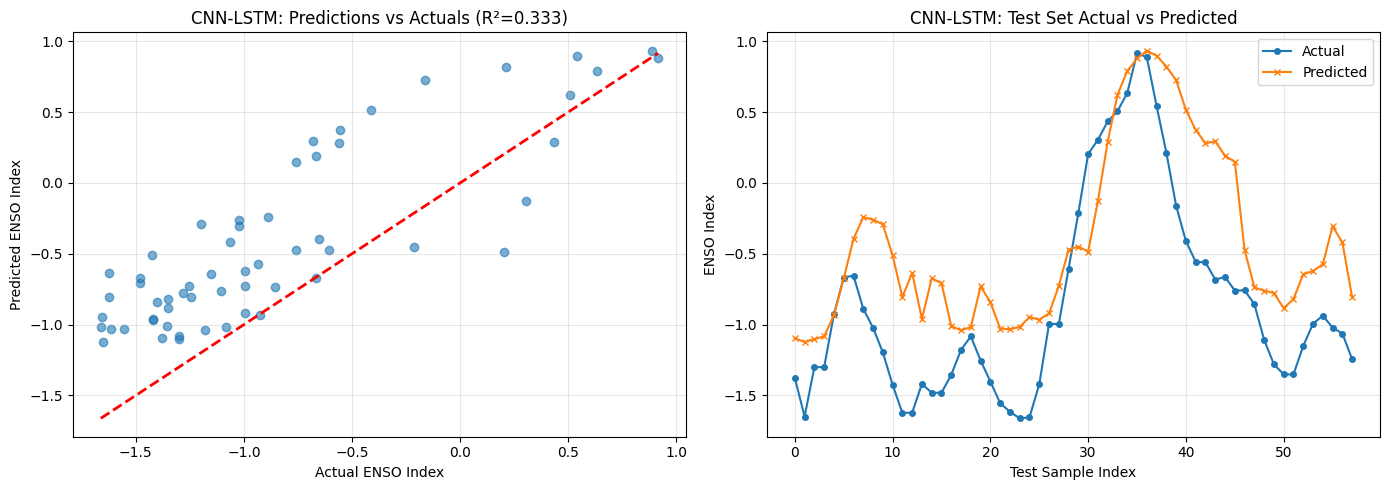

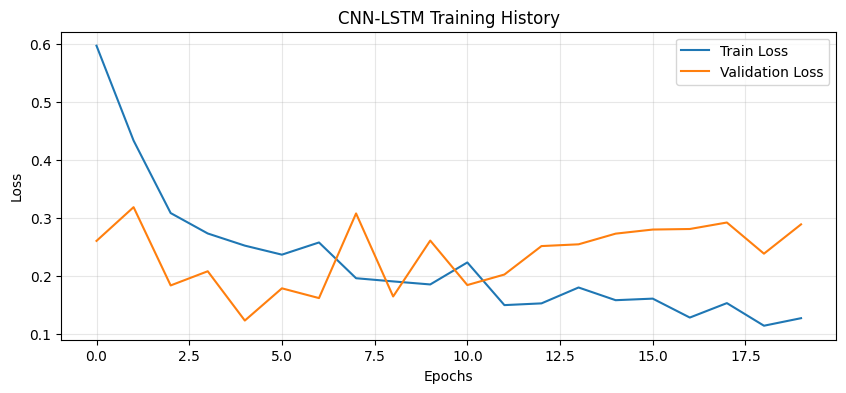

In [18]:
# Evaluate CNN-LSTM
test_predictions = cnn_lstm_model.predict(X_test)
test_actuals = y_test.reshape(-1, 1)

r2 = r2_score(test_actuals, test_predictions)
print(f"\nCNN-LSTM R² Score: {r2:.4f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(test_actuals, test_predictions, alpha=0.6)
plt.plot([test_actuals.min(), test_actuals.max()], 
         [test_actuals.min(), test_actuals.max()], 
         'r--', lw=2)
plt.xlabel('Actual ENSO Index')
plt.ylabel('Predicted ENSO Index')
plt.title(f'CNN-LSTM: Predictions vs Actuals (R²={r2:.3f})')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(test_actuals, label='Actual', marker='o', markersize=4)
plt.plot(test_predictions, label='Predicted', marker='x', markersize=4)
plt.xlabel('Test Sample Index')
plt.ylabel('ENSO Index')
plt.title('CNN-LSTM: Test Set Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Training history
plt.figure(figsize=(10, 4))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN-LSTM Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


CNN-LSTM Classification Accuracy: 72.41%


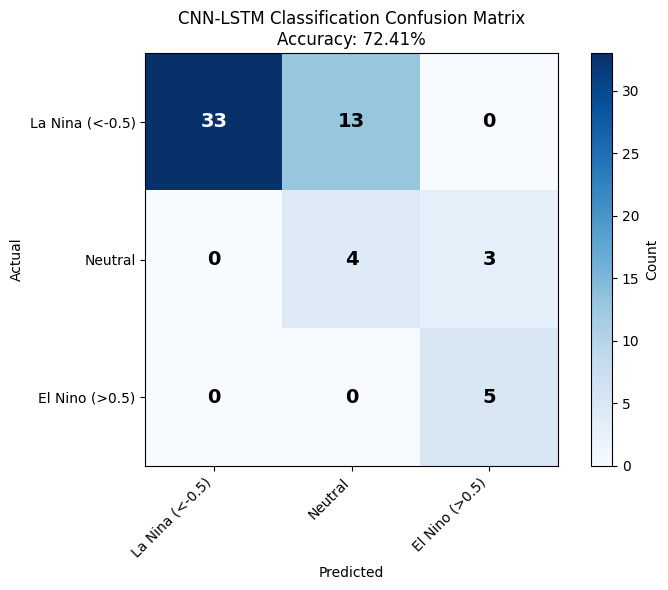

In [19]:
# Classification evaluation for CNN-LSTM
test_actuals_class = classify_enso(test_actuals.flatten())
test_predictions_class = classify_enso(test_predictions.flatten())

accuracy = accuracy_score(test_actuals_class, test_predictions_class)
print(f"\nCNN-LSTM Classification Accuracy: {accuracy*100:.2f}%")

conf_matrix = confusion_matrix(test_actuals_class, test_predictions_class)

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar(label='Count')
plt.xticks([0, 1, 2], class_names, rotation=45, ha='right')
plt.yticks([0, 1, 2], class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'CNN-LSTM Classification Confusion Matrix\nAccuracy: {accuracy:.2%}')

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(conf_matrix[i, j]), 
                ha='center', va='center', 
                color='white' if conf_matrix[i, j] > conf_matrix.max()/2 else 'black',
                fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

switch to phase classification instead of intensity regression then classification

In [ ]:
seq_length = 9
X_seq, y_seq = create_sequences(ssta_normalized, enso_intensities, seq_length)

# convert targets to one-hot encoded classes
y_classes = classify_enso(y_seq)
y_onehot = tf.keras.utils.to_categorical(y_classes, num_classes=3)

Sequence shape: (385, 9, 5, 26, 1)
Target shape: (385, 3)


In [53]:
n_samples = len(X_seq)
train_end = int(0.6 * n_samples)
val_end = int(0.75 * n_samples) 

X_train, y_train = X_seq[:train_end], y_onehot[:train_end]
X_val, y_val = X_seq[train_end:val_end], y_onehot[train_end:val_end]
X_test, y_test = X_seq[val_end:], y_onehot[val_end:]

y_test_classes = y_classes[val_end:]

In [ ]:
from tensorflow.keras.layers import Bidirectional

cnn_lstm_class = Sequential([
    layers.Input(shape=(seq_length, lat_size, lon_size, 1)),
    
    TimeDistributed(layers.Conv2D(32, 3, padding='same', activation='relu')),
    TimeDistributed(layers.BatchNormalization()),
    TimeDistributed(layers.MaxPooling2D(pool_size=(2, 2))),
    
    TimeDistributed(layers.Flatten()),
    
    Bidirectional(LSTM(24)),
    layers.Dropout(0.3),
    
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

cnn_lstm_class.compile(
    optimizer=Adam(learning_rate=0.0012),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_lstm_class.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_28             │ (None, 9, 5, 26, 32)   │           320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_29             │ (None, 9, 5, 26, 32)   │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_30             │ (None, 9, 2, 13, 32)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_31             │ (None, 9, 832)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 48)             │       164,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,659 (651.01 KB)

 Trainable params: 166,595 (650.76 KB)

 Non-trainable params: 64 (256.00 B)

In [55]:
early_stopping = EarlyStopping(
    monitor='val_accuracy',  
    mode='max',              
    patience=10,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history_class = cnn_lstm_class.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 183ms/step - accuracy: 0.6147 - loss: 0.9040 - val_accuracy: 0.5965 - val_loss: 0.9715 - learning_rate: 0.0012
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7056 - loss: 0.6938 - val_accuracy: 0.5965 - val_loss: 0.8625 - learning_rate: 0.0012
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.7229 - loss: 0.6305 - val_accuracy: 0.5789 - val_loss: 0.8490 - learning_rate: 0.0012
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7749 - loss: 0.5445 - val_accuracy: 0.6842 - val_loss: 0.7879 - learning_rate: 0.0012
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7879 - loss: 0.5340 - val_accuracy: 0.6491 - val_loss: 0.8191 - learning_rate: 0.0012
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.8268 - loss: 0.4332 - val_accuracy: 0.6316 - val_loss: 0.7941 - learning_rate: 0.0012
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.8225 - loss: 0.4432 

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 473ms/step

Classification Accuracy: 67.01%


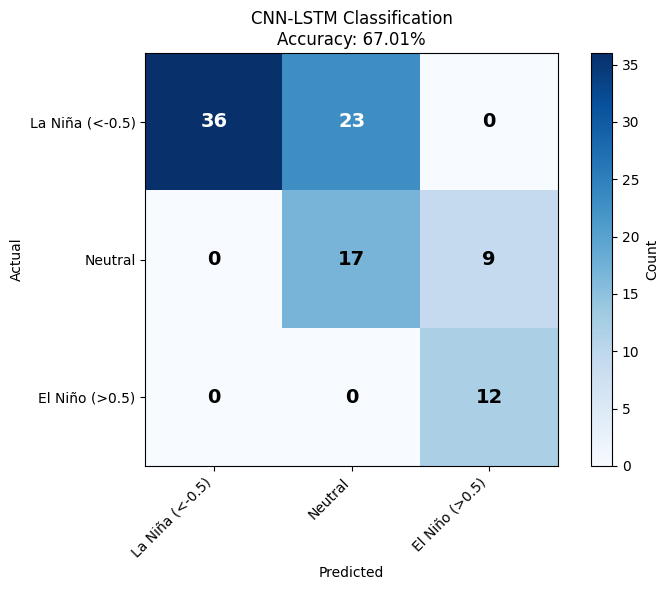

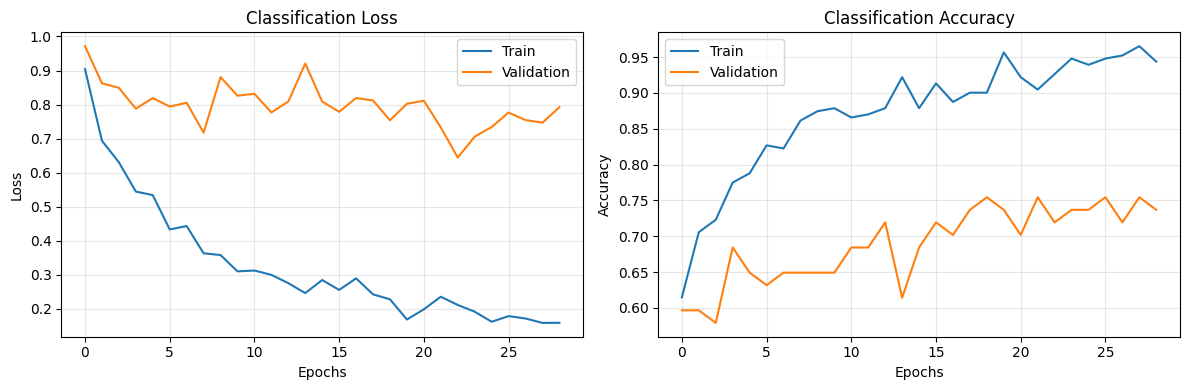

In [ ]:
test_pred_probs = cnn_lstm_class.predict(X_test)
test_pred_classes = np.argmax(test_pred_probs, axis=1)

accuracy = accuracy_score(y_test_classes, test_pred_classes)
print(f"\nClassification Accuracy: {accuracy*100:.2f}%")

# Confusion matrix
class_names = ['La Nina (<-0.5)', 'Neutral', 'El Nino (>0.5)']
conf_matrix = confusion_matrix(y_test_classes, test_pred_classes)

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar(label='Count')
plt.xticks([0, 1, 2], class_names, rotation=45, ha='right')
plt.yticks([0, 1, 2], class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'CNN-LSTM Classification\nAccuracy: {accuracy:.2%}')

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(conf_matrix[i, j]), 
                ha='center', va='center', 
                color='white' if conf_matrix[i, j] > conf_matrix.max()/2 else 'black',
                fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_class.history['loss'], label='Train')
axes[0].plot(history_class.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Classification Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_class.history['accuracy'], label='Train')
axes[1].plot(history_class.history['val_accuracy'], label='Validation')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Classification Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

hyperparameter tuning

In [57]:
hyperparams = {
    'seq_length': [6,9],
    'lstm': [24,32,48],
    'learning_rate': [0.0005,0.008,0.001]
}
results = []
for seq in hyperparams['seq_length']:
    for lstm_val in hyperparams['lstm']:
        for learn_rate in hyperparams['learning_rate']:

            X_seq, y_seq = create_sequences(ssta_normalized, enso_intensities, seq)
            y_classes = classify_enso(y_seq)
            y_onehot = tf.keras.utils.to_categorical(y_classes, num_classes=3)

            n = len(X_seq)
            train_end, val_end = int(0.7*n), int(0.85*n)
            X_train, y_train = X_seq[:train_end], y_onehot[:train_end]
            X_val, y_val = X_seq[train_end:val_end], y_onehot[train_end:val_end]
            X_test, y_test = X_seq[val_end:], y_onehot[val_end:]
            y_test_classes = y_classes[val_end:]
            
            model = Sequential([
                layers.Input(shape=(seq, lat_size, lon_size, 1)),
                TimeDistributed(layers.Conv2D(32, 3, padding='same', activation='relu')),
                TimeDistributed(layers.BatchNormalization()),
                TimeDistributed(layers.MaxPooling2D(pool_size=(2, 2))),
                TimeDistributed(layers.Flatten()),
                LSTM(lstm_val),
                layers.Dropout(0.3),
                layers.Dense(32, activation='relu'),
                layers.Dropout(0.2),
                layers.Dense(3, activation='softmax')
            ])

            model.compile(optimizer=Adam(learning_rate=learn_rate),
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    

            model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=50, batch_size=16, verbose=0,
              callbacks=[EarlyStopping(patience=10, restore_best_weights=True)])
    
            pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
            acc = accuracy_score(y_test_classes, pred)
            
            results.append({'seq_len': seq, 'lstm': lstm_val, 'lr': learn_rate, 'acc': acc})
            print(f"seq={seq}, lstm={lstm_val}, lr={learn_rate}: {acc:.2%}")

seq=6, lstm=24, lr=0.0005: 74.58%
seq=6, lstm=24, lr=0.008: 79.66%
seq=6, lstm=24, lr=0.001: 72.88%
seq=6, lstm=32, lr=0.0005: 74.58%
seq=6, lstm=32, lr=0.008: 76.27%
seq=6, lstm=32, lr=0.001: 79.66%
seq=6, lstm=48, lr=0.0005: 79.66%
seq=6, lstm=48, lr=0.008: 74.58%
seq=6, lstm=48, lr=0.001: 76.27%
seq=9, lstm=24, lr=0.0005: 75.86%
seq=9, lstm=24, lr=0.008: 58.62%
seq=9, lstm=24, lr=0.001: 79.31%
seq=9, lstm=32, lr=0.0005: 72.41%
seq=9, lstm=32, lr=0.008: 74.14%
seq=9, lstm=32, lr=0.001: 77.59%
seq=9, lstm=48, lr=0.0005: 79.31%
seq=9, lstm=48, lr=0.008: 75.86%
seq=9, lstm=48, lr=0.001: 70.69%


In [58]:
results_df = pd.DataFrame(results).sort_values('acc', ascending=False)
print(results_df.head(10))

    seq_len  lstm      lr       acc
1         6    24  0.0080  0.796610
5         6    32  0.0010  0.796610
6         6    48  0.0005  0.796610
15        9    48  0.0005  0.793103
11        9    24  0.0010  0.793103
14        9    32  0.0010  0.775862
4         6    32  0.0080  0.762712
8         6    48  0.0010  0.762712
16        9    48  0.0080  0.758621
9         9    24  0.0005  0.758621


final run with best performer

seq=6, lstm=24, lr=0.0008: 77.97%

Classification Accuracy: 77.97%


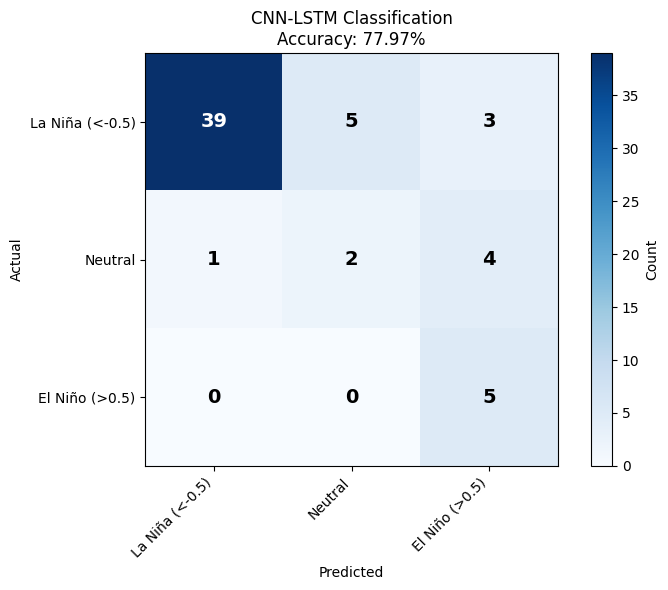

In [61]:
seq = 6
lstm_val = 24
learn_rate = 0.0008

X_seq, y_seq = create_sequences(ssta_normalized, enso_intensities, seq)
y_classes = classify_enso(y_seq)
y_onehot = tf.keras.utils.to_categorical(y_classes, num_classes=3)

n = len(X_seq)
train_end, val_end = int(0.7*n), int(0.85*n)
X_train, y_train = X_seq[:train_end], y_onehot[:train_end]
X_val, y_val = X_seq[train_end:val_end], y_onehot[train_end:val_end]
X_test, y_test = X_seq[val_end:], y_onehot[val_end:]
y_test_classes = y_classes[val_end:]

model = Sequential([
    layers.Input(shape=(seq, lat_size, lon_size, 1)),
    TimeDistributed(layers.Conv2D(32, 3, padding='same', activation='relu')),
    TimeDistributed(layers.BatchNormalization()),
    TimeDistributed(layers.MaxPooling2D(pool_size=(2, 2))),
    TimeDistributed(layers.Flatten()),
    LSTM(lstm_val),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=learn_rate),
        loss='categorical_crossentropy', 
        metrics=['accuracy'])


model.fit(X_train, y_train, validation_data=(X_val, y_val),
    epochs=50, batch_size=16, verbose=0,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)])

pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
acc = accuracy_score(y_test_classes, pred)

results.append({'seq_len': seq, 'lstm': lstm_val, 'lr': learn_rate, 'acc': acc})
print(f"seq={seq}, lstm={lstm_val}, lr={learn_rate}: {acc:.2%}")

accuracy = accuracy_score(y_test_classes, pred)
print(f"\nClassification Accuracy: {accuracy*100:.2f}%")

# Confusion matrix
class_names = ['La Nina (<-0.5)', 'Neutral', 'El Nino (>0.5)']
conf_matrix = confusion_matrix(y_test_classes, pred)

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar(label='Count')
plt.xticks([0, 1, 2], class_names, rotation=45, ha='right')
plt.yticks([0, 1, 2], class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'CNN-LSTM Classification\nAccuracy: {accuracy:.2%}')

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(conf_matrix[i, j]), 
                ha='center', va='center', 
                color='white' if conf_matrix[i, j] > conf_matrix.max()/2 else 'black',
                fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()